# Guided tour — every feature on one dataset

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pypackage_template/blob/main/docs/notebooks/tour.ipynb)

`mypackage` is the worked example shipped with this project template: a dependency-free library for descriptive statistics, smoothing, and composable transforms over one-dimensional numeric series. This notebook runs through the whole public API on a single synthetic dataset, so you can see how the three layers fit together.

**What you'll learn:**

1. Batch statistics with `summarize`, and streaming statistics with `RunningStats`.
2. The three smoothing filters and how their failure modes differ.
3. The fit / apply lifecycle, and why `Pipeline` fits sequentially.
4. Writing a transform of your own that composes with the built-ins.
5. The typed exception hierarchy.

## Background

The library is organised in three layers, each usable on its own:

| Layer | Style | Entry points |
| --- | --- | --- |
| Statistics | pure functions + one accumulator | `summarize`, `quantile`, `zscores`, `RunningStats` |
| Smoothing | pure functions | `moving_average`, `exponential_moving_average`, `median_filter` |
| Transforms | objects with `fit` / `apply` | `Standardize`, `MinMaxScale`, `Clip`, `MovingAverage`, `Pipeline` |

Everything operates on any `Sequence[float]` — a list, a tuple, a `range` — and every function returns a **new** list. Nothing is ever mutated in place, which is what makes the layers safe to compose in any order.

## Setup

Detect Colab and install the package only when running there. Local and CI users with the environment already set up skip the install and go straight to the imports.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "matplotlib",
            "watermark",
            "mypackage @ git+https://github.com/jejjohnson/pypackage_template@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import matplotlib.pyplot as plt
import numpy as np

import mypackage as mp

Print an explicit version and platform readout so reproducing this notebook later is unambiguous.

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic("watermark", "-v -m -p numpy,matplotlib,mypackage")
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.12.3
IPython version      : 9.10.0

numpy     : 2.4.4
matplotlib: 3.11.0
mypackage : 0.1.6

Compiler    : GCC 13.3.0
OS          : Linux
Release     : 6.18.44-fc-v37
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit



## A dataset with every pathology

We build a signal that exercises each part of the API: a slow trend, additive Gaussian noise, and three isolated spikes. NumPy is used here only to *generate* the data — `mypackage` itself never sees an array and has no NumPy dependency.

In [4]:
rng = np.random.default_rng(seed=42)

n_samples = 240
time = np.linspace(0.0, 4.0 * np.pi, n_samples)
trend = np.sin(time) + 0.25 * time
noise = rng.normal(loc=0.0, scale=0.35, size=n_samples)

signal = trend + noise
for index in (60, 140, 200):
    signal[index] += 8.0

# The library works on plain Python sequences.
series: list[float] = signal.tolist()
truth: list[float] = trend.tolist()

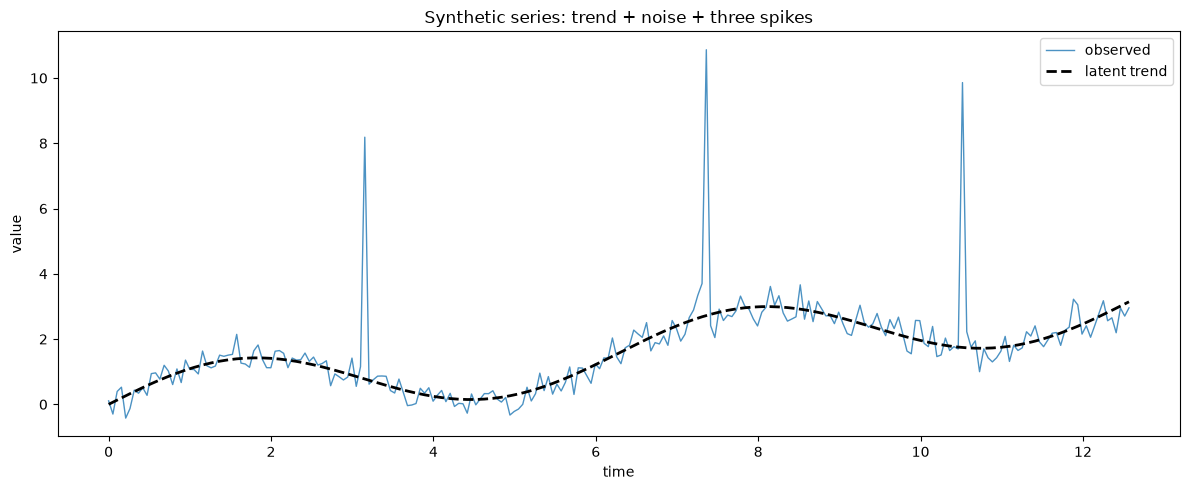

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(time, series, color="C0", lw=1.0, alpha=0.8, label="observed")
ax.plot(time, truth, "k--", lw=2.0, label="latent trend")
ax.set_xlabel("time")
ax.set_ylabel("value")
ax.set_title("Synthetic series: trend + noise + three spikes")
ax.legend()
plt.tight_layout()
plt.show()

## Layer 1 — descriptive statistics

`summarize` makes one pass and returns a frozen `Summary` dataclass. Being frozen means it is immutable, hashable, and comparable, so it is safe to cache or use as a test fixture.

In [6]:
summary = mp.summarize(series)

print(f"count    {summary.count}")
print(f"mean     {summary.mean:.4f}")
print(f"median   {summary.median:.4f}")
print(f"std      {summary.std:.4f}")
print(f"min/max  {summary.minimum:.4f} / {summary.maximum:.4f}")
print(f"spread   {summary.spread:.4f}")

count    240
mean     1.6543
median   1.5670
std      1.3264
min/max  -0.4215 / 10.8663
spread   11.2878


Notice how far apart the mean and the median are: that gap is the three spikes pulling the mean upward while leaving the median essentially untouched. This is the same robustness argument that makes the median *filter* useful later on.

`to_dict` adds the derived properties so the summary is directly serialisable or renderable as a table.

In [7]:
for key, value in sorted(summary.to_dict().items()):
    print(f"{key:<10}{value:>12.4f}")

count         240.0000
ddof            1.0000
maximum        10.8663
mean            1.6543
median          1.5670
minimum        -0.4215
spread         11.2878
std             1.3264
variance        1.7595


Quantiles use linear interpolation between order statistics, matching NumPy's default `method="linear"`.

In [8]:
levels = [0.0, 0.05, 0.25, 0.5, 0.75, 0.95, 1.0]
ours = [mp.quantile(series, q) for q in levels]
numpy_reference = np.quantile(signal, levels)

print(f"{'q':>6}  {'mypackage':>12}  {'numpy':>12}  {'|diff|':>10}")
print("-" * 46)
for q, mine, theirs in zip(levels, ours, numpy_reference, strict=True):
    print(f"{q:>6.2f}  {mine:>12.6f}  {theirs:>12.6f}  {abs(mine - theirs):>10.2e}")

     q     mypackage         numpy      |diff|
----------------------------------------------
  0.00     -0.421515     -0.421515    0.00e+00
  0.05      0.016602      0.016602    3.47e-18
  0.25      0.820235      0.820235    1.11e-16
  0.50      1.567024      1.567024    0.00e+00
  0.75      2.403014      2.403014    0.00e+00
  0.95      3.150650      3.150650    0.00e+00
  1.00     10.866258     10.866258    0.00e+00


### Streaming statistics

When the data arrives incrementally — or does not fit in memory — `RunningStats` folds one observation at a time into a running mean and sum of squared deviations using Welford's algorithm, in constant space.

In [9]:
stats = mp.RunningStats()
running_means: list[float] = []
running_stds: list[float] = []

for value in series:
    stats.update(value)
    running_means.append(stats.mean)
    running_stds.append(stats.std)

print(f"streaming mean     {stats.mean:.12f}")
print(f"batch mean         {summary.mean:.12f}")
print(f"streaming variance {stats.variance:.12f}")
print(f"batch variance     {summary.variance:.12f}")

streaming mean     1.654343193212
batch mean         1.654343193212
streaming variance 1.759464826283
batch variance     1.759464826283


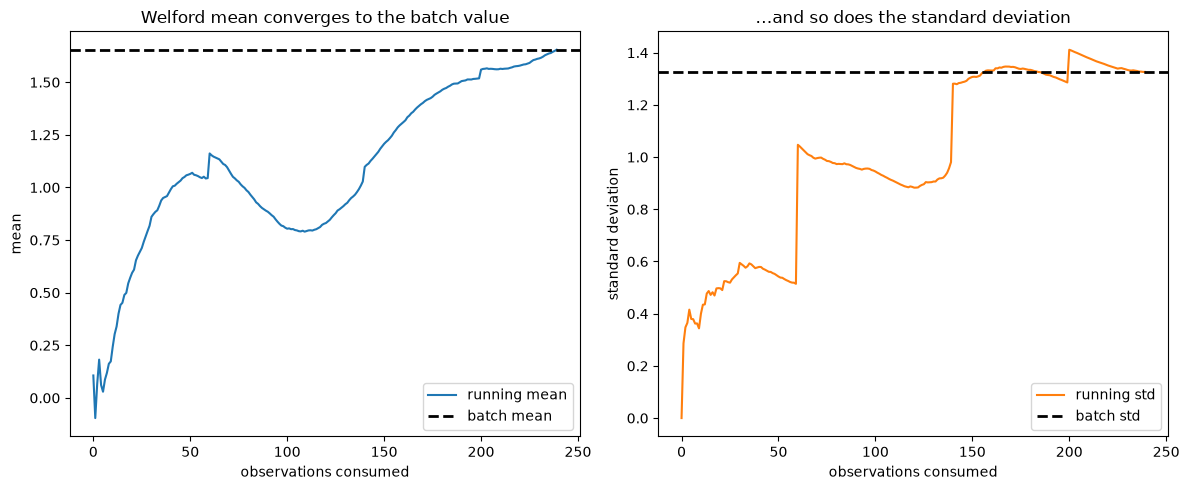

In [10]:
fig, (ax_mean, ax_std) = plt.subplots(1, 2, figsize=(12, 5))

ax_mean.plot(running_means, color="C0", label="running mean")
ax_mean.axhline(summary.mean, color="k", ls="--", lw=2.0, label="batch mean")
ax_mean.set_xlabel("observations consumed")
ax_mean.set_ylabel("mean")
ax_mean.set_title("Welford mean converges to the batch value")
ax_mean.legend()

ax_std.plot(running_stds, color="C1", label="running std")
ax_std.axhline(summary.std, color="k", ls="--", lw=2.0, label="batch std")
ax_std.set_xlabel("observations consumed")
ax_std.set_ylabel("standard deviation")
ax_std.set_title("…and so does the standard deviation")
ax_std.legend()

plt.tight_layout()
plt.show()

The three visible jumps are the spikes entering the accumulator.

### Why Welford rather than the textbook formula

The naive identity $s^2 = \left(\sum x_i^2 - (\sum x_i)^2 / N\right) / (N-1)$ subtracts two nearly equal large numbers. Offset a tiny series by $10^9$ and it loses every significant digit — and returns a negative variance, which is not a number a variance can be.

In [11]:
offset = 1e9
shifted = [offset + delta for delta in (1.0, 2.0, 3.0, 4.0)]

n = len(shifted)
naive = (sum(v * v for v in shifted) - sum(shifted) ** 2 / n) / (n - 1)

print(f"exact answer        {5 / 3:.12f}")
print(f"mypackage.summarize {mp.summarize(shifted).variance:.12f}")
print(f"RunningStats        {mp.RunningStats().update_many(shifted).variance:.12f}")
print(f"naive formula       {naive:.12f}   <-- wrong sign, wrong magnitude")

exact answer        1.666666666667
mypackage.summarize 1.666666666667
RunningStats        1.666666666667
naive formula       0.000000000000   <-- wrong sign, wrong magnitude


## Layer 2 — smoothing

Three filters, each with a different failure mode. The deep-dive notebook explores them properly; here we just see all three side by side.

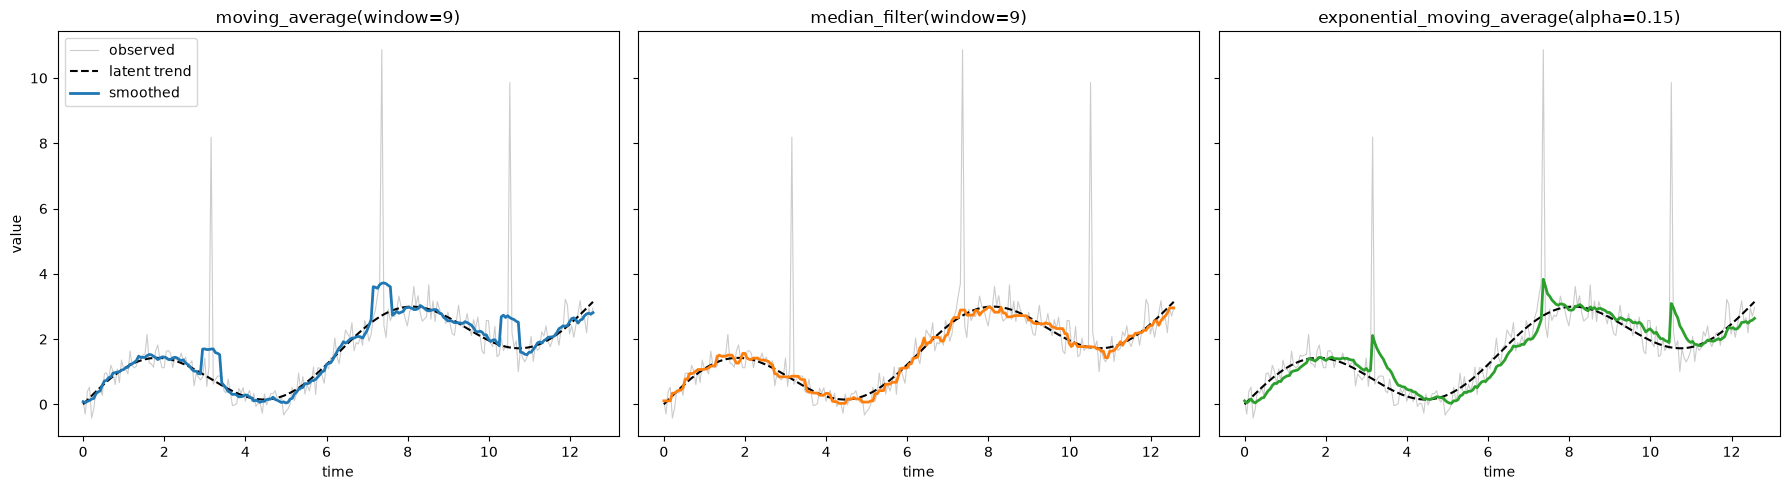

In [12]:
window = 9
mean_smoothed = mp.moving_average(series, window=window)
median_smoothed = mp.median_filter(series, window=window)
ewma_smoothed = mp.exponential_moving_average(series, alpha=0.15)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
panels = [
    (axes[0], mean_smoothed, f"moving_average(window={window})", "C0"),
    (axes[1], median_smoothed, f"median_filter(window={window})", "C1"),
    (axes[2], ewma_smoothed, "exponential_moving_average(alpha=0.15)", "C2"),
]

for ax, smoothed, title, color in panels:
    ax.plot(time, series, color="0.8", lw=0.8, label="observed")
    ax.plot(time, truth, "k--", lw=1.5, label="latent trend")
    ax.plot(time, smoothed, color=color, lw=2.0, label="smoothed")
    ax.set_xlabel("time")
    ax.set_title(title)
axes[0].set_ylabel("value")
axes[0].legend()
plt.tight_layout()
plt.show()

The mean filter spreads each spike over nine samples; the median filter deletes them outright; the exponential filter attenuates them but lags the trend. Quantifying that:

In [13]:
def rmse(estimate: list[float], reference: list[float]) -> float:
    """Root-mean-square error against the known latent trend."""
    squared = [(a - b) ** 2 for a, b in zip(estimate, reference, strict=True)]
    return mp.summarize(squared, ddof=0).mean ** 0.5


candidates = {
    "raw": series,
    f"moving_average({window})": mean_smoothed,
    f"median_filter({window})": median_smoothed,
    "ewma(0.15)": ewma_smoothed,
}

print(f"{'filter':<24}{'RMSE vs trend':>15}")
print("-" * 39)
for label, values in candidates.items():
    print(f"{label:<24}{rmse(values, truth):>15.4f}")

filter                    RMSE vs trend
---------------------------------------
raw                              0.9368
moving_average(9)                0.3160
median_filter(9)                 0.1219
ewma(0.15)                       0.3487


## Layer 3 — transforms

A transform is any object with an `apply` method. Stateful ones — `Standardize`, `MinMaxScale` — learn from data in `fit` and raise `NotFittedError` if used before that.

In [14]:
scaler = mp.Standardize()

try:
    scaler.apply(series)
except mp.NotFittedError as err:
    print(f"NotFittedError: {err}")

scaler.fit(series)
print(f"learned mean = {scaler.mean_:.4f}, learned std = {scaler.std_:.4f}")

NotFittedError: Standardize is not fitted; call .fit(series) first
learned mean = 1.6543, learned std = 1.3264


Keeping `fit` and `apply` separate is what prevents leakage: the statistics are learned once, on a reference split, and reused everywhere else.

In [15]:
split = 160
train, test = series[:split], series[split:]

leak_free = mp.Standardize().fit(train)
print(f"fitted on train only: mean={leak_free.mean_:.4f}, std={leak_free.std_:.4f}")

refitted = mp.Standardize().fit(test)
print(f"if refitted on test:  mean={refitted.mean_:.4f}, std={refitted.std_:.4f}")
print("\nThose differ — which is exactly the information that would leak.")

fitted on train only: mean=1.3028, std=1.3319
if refitted on test:  mean=2.3575, std=1.0009

Those differ — which is exactly the information that would leak.


`inverse` round-trips back to the original scale.

In [16]:
round_tripped = leak_free.inverse(leak_free.apply(train))
largest_error = max(abs(a - b) for a, b in zip(train, round_tripped, strict=True))
print(f"largest round-trip error: {largest_error:.2e}")

largest round-trip error: 4.44e-16


### Pipelines

`Pipeline` applies steps left to right, and fits each step on the *output of the previous one* — exactly the data that step will see at apply time.

In [17]:
pipeline = mp.chain(
    mp.Clip(upper=6.0),  # knock the spikes down first
    mp.MovingAverage(window=9),  # then smooth
    mp.Standardize(),  # finally centre and scale
)

cleaned = pipeline.fit_apply(series)

print(f"steps: {[type(step).__name__ for step in pipeline]}")
cleaned_summary = mp.summarize(cleaned)
print(f"output mean {cleaned_summary.mean:.2e}, std {cleaned_summary.std:.4f}")

steps: ['Clip', 'MovingAverage', 'Standardize']
output mean 1.42e-16, std 1.0000


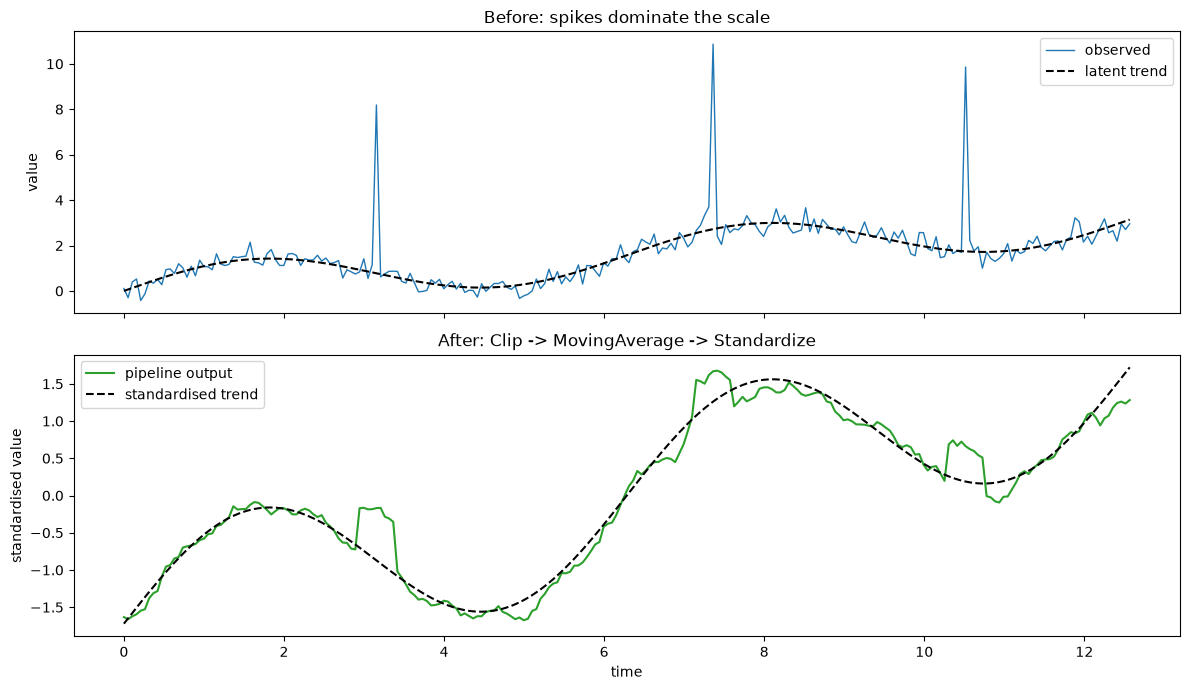

In [18]:
fig, (ax_raw, ax_clean) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax_raw.plot(time, series, color="C0", lw=1.0, label="observed")
ax_raw.plot(time, truth, "k--", lw=1.5, label="latent trend")
ax_raw.set_ylabel("value")
ax_raw.set_title("Before: spikes dominate the scale")
ax_raw.legend()

ax_clean.plot(time, cleaned, color="C2", lw=1.5, label="pipeline output")
standardised_truth = mp.Standardize().fit_apply(truth)
ax_clean.plot(time, standardised_truth, "k--", lw=1.5, label="standardised trend")
ax_clean.set_xlabel("time")
ax_clean.set_ylabel("standardised value")
ax_clean.set_title("After: Clip -> MovingAverage -> Standardize")
ax_clean.legend()

plt.tight_layout()
plt.show()

Order matters, and the sequential fit is why. If `Standardize` were fitted on the raw series instead of on the clipped, smoothed one, its learned standard deviation would be inflated by the very spikes the earlier steps exist to remove.

In [19]:
sequential = pipeline[2]
naive_scaler = mp.Standardize().fit(series)

print(f"std learned after Clip + MovingAverage : {sequential.std_:.4f}")
print(f"std learned on the raw series          : {naive_scaler.std_:.4f}")

std learned after Clip + MovingAverage : 0.9359
std learned on the raw series          : 1.3264


Pipelines compose with `|`, and neither operand is mutated — you always get a new pipeline.

In [20]:
extended = pipeline | mp.Clip(-2.0, 2.0)
print(f"original: {len(pipeline)} steps, extended: {len(extended)} steps")

original: 3 steps, extended: 4 steps


### Writing your own transform

The `Transform` protocol is structural, so a user-defined class satisfies it without inheriting from anything or registering anywhere.

In [21]:
from dataclasses import dataclass

from mypackage import Series


@dataclass(frozen=True, slots=True)
class Detrend:
    """Subtract a rolling baseline estimated by a median filter."""

    window: int

    def fit(self, series: Series) -> "Detrend":
        return self

    def apply(self, series: Series) -> list[float]:
        baseline = mp.median_filter(series, self.window)
        return [value - base for value, base in zip(series, baseline, strict=True)]


detrender = Detrend(window=31)
print(f"isinstance(Detrend(31), mp.Transform) -> {isinstance(detrender, mp.Transform)}")

residual = mp.chain(mp.Clip(upper=6.0), detrender).fit_apply(series)

isinstance(Detrend(31), mp.Transform) -> True


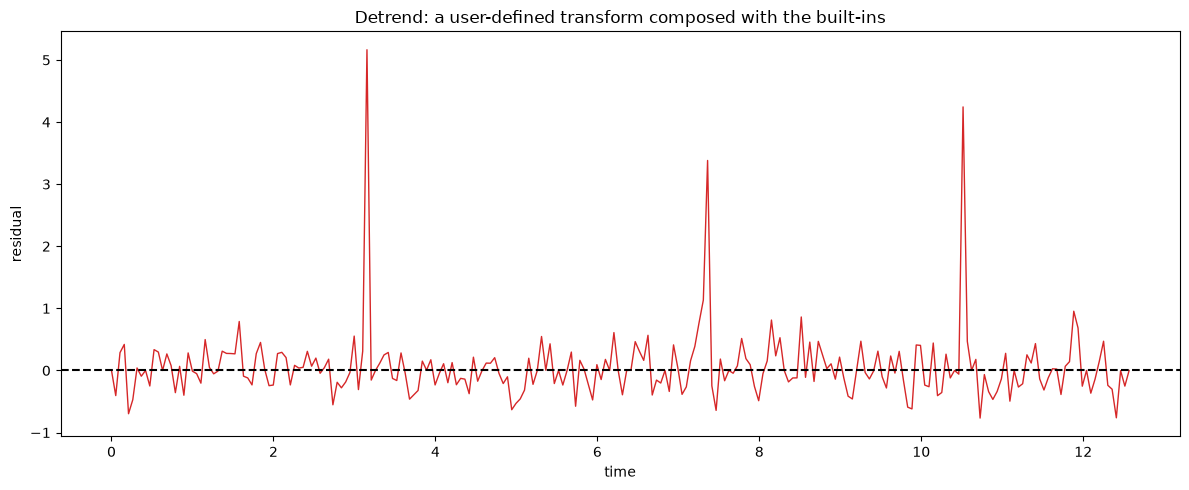

residual mean 0.0541
residual std  0.5766


In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(time, residual, color="C3", lw=1.0)
ax.axhline(0.0, color="k", ls="--", lw=1.5)
ax.set_xlabel("time")
ax.set_ylabel("residual")
ax.set_title("Detrend: a user-defined transform composed with the built-ins")
plt.tight_layout()
plt.show()

print(f"residual mean {mp.summarize(residual).mean:.4f}")
print(f"residual std  {mp.summarize(residual).std:.4f}")

## Error handling

Every failure raises a typed exception. All of them derive from `MypackageError`, and each also derives from the closest standard-library exception, so code written against the stdlib keeps working.

In [23]:
failures = [
    ("empty series", lambda: mp.summarize([])),
    ("non-numeric input", lambda: mp.summarize([1.0, "two"])),
    ("window too large", lambda: mp.moving_average([1.0, 2.0], window=99)),
    ("alpha out of range", lambda: mp.exponential_moving_average([1.0], alpha=2.0)),
    ("constant series", lambda: mp.zscores([3.0, 3.0, 3.0])),
    ("unfitted transform", lambda: mp.Standardize().apply([1.0])),
    ("bad pipeline step", lambda: mp.Pipeline(["not a transform"])),
]

for label, call in failures:
    try:
        call()
    except mp.MypackageError as err:
        print(f"{label:<20} {type(err).__name__:<20} {err}")

empty series         EmptySeriesError     'series' must contain at least one value, got 0
non-numeric input    ValidationError      'series' must contain only numbers, got 'two' at index 1
window too large     ValidationError      'window' must not exceed the series length, got window=99 for 2 value(s)
alpha out of range   ValidationError      'alpha' must lie in (0, 1], got 2.0
constant series      ValidationError      cannot standardise a constant series (std == 0)
unfitted transform   NotFittedError       Standardize is not fitted; call .fit(series) first
bad pipeline step    ValidationError      pipeline step 0 does not implement Transform.apply, got 'not a transform'


In [24]:
print(
    f"EmptySeriesError is a ValueError: {issubclass(mp.EmptySeriesError, ValueError)}"
)
print(
    f"NotFittedError is a RuntimeError: {issubclass(mp.NotFittedError, RuntimeError)}"
)

EmptySeriesError is a ValueError: True
NotFittedError is a RuntimeError: True


## Utilities

`Window[T]` is a generic fixed-capacity ring buffer — the same one `median_filter` uses internally — and `timer()` is a context manager for quick wall-clock measurements.

In [25]:
window_buffer: mp.Window[int] = mp.Window(capacity=3)
for value in (1, 2, 3, 4, 5):
    window_buffer.push(value)
print(f"{window_buffer!r}  is_full={window_buffer.is_full}")

with mp.timer() as elapsed:
    for _ in range(200):
        mp.moving_average(series, window=9)
print(f"200 x moving_average(240 samples, window=9): {elapsed.milliseconds:.1f} ms")

Window(capacity=3, items=[3, 4, 5])  is_full=True
200 x moving_average(240 samples, window=9): 16.5 ms


## Summary

1. **Statistics** — `summarize` returns a frozen `Summary`; `RunningStats` gives the same answers in constant memory, and both are numerically stable where the textbook formula is not.
2. **Smoothing** — the mean filter smears spikes, the median filter deletes them, the exponential filter lags; picking one is a choice about what to preserve.
3. **Transforms** — `fit` and `apply` are separate so statistics can be learned once and reused; `Pipeline` fits sequentially so each step sees the data it will actually be given.
4. **Extensibility** — `Transform` is a structural protocol, so your own classes compose with the built-ins without inheriting from anything.
5. **Errors** — one hierarchy rooted at `MypackageError`, with each member also subclassing the nearest stdlib exception.

Next: the [smoothing deep dive](smoothing_deep_dive.ipynb) works through filter selection, boundary handling, and window tuning quantitatively.